# 클래스 불균형
- 클래스 불균형(Class Imbalances) 문제의 경우 알고리즘이 다수 클래스를 더 많이 예측하는 방향으로 편향되는 경향이 있음. 따라서 소수 클래스에서 오분류율이 높아짐
- 비즈니스 상황에서 클래스 불균형은 흔한 현상
    - 금융 비정상 거래 예측 : 정상 > 비정상(사기거래)
    - 제조 공정간 불량 예측 : 정상 > 불량
- 이러한 경우 왜 문제인가?
    - 정확도(Accuracy)는 높지만, 소수 클래스의 재현율(Recall)는 형편없이 낮음

- 해결방법1 : Resampling
    - Under Sampling : 다수 클래스 데이터를 소수 클래스 수 만큼 랜덤 샘플링
    - Over Sampling : 소수 클래스 데이터를 다수 클래스 수 만큼 랜덤 샘플링

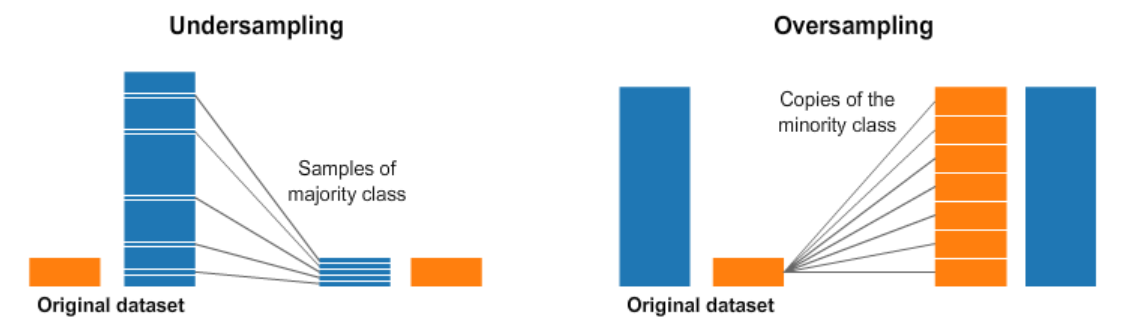

- 해결방법2 : Class Weight
    - Resampling 없이 클래스에 가중치를 부여하여 클래스 불균형 문제 해결
        - 학습 중 소수 클래스에 더 많은 가중치를 부여
        - 소수 클래스에 대한 오류를 줄이는 효과

# 1.환경 준비

In [14]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format = 'retina'

In [15]:
# 데이터 읽어오기
path = 'data/attrition2.csv'
df = pd.read_csv(path)

# 2.데이터 이해

In [16]:
# 상위 몇 개 행 확인
df.head()

,Attrition,Age,Department,DistanceFromHome,Education,EducationField,Gender,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,RelationshipSatisfaction,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany
0,0,28,Research & Development,1,3,Medical,Female,Research Scientist,1,Married,3591,1,3,3,3,3,3
1,1,37,Research & Development,2,2,Other,Male,Laboratory Technician,3,Single,2090,6,2,7,3,3,0
2,0,27,Research & Development,8,5,Life Sciences,Male,Laboratory Technician,3,Married,4621,1,4,3,4,3,3
3,0,18,Research & Development,1,3,Life Sciences,Female,Laboratory Technician,4,Single,1611,1,3,0,5,4,0
4,0,29,Research & Development,9,3,Life Sciences,Male,Research Scientist,3,Married,2451,6,1,5,2,2,1


In [17]:
# 하위 몇 개 행 확인
df.tail()

,Attrition,Age,Department,DistanceFromHome,Education,EducationField,Gender,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,RelationshipSatisfaction,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany
1145,0,33,Research & Development,1,2,Life Sciences,Female,Research Director,4,Single,13458,1,3,15,1,3,15
1146,0,36,Research & Development,24,4,Life Sciences,Female,Laboratory Technician,2,Married,5674,7,3,11,3,3,9
1147,0,40,Research & Development,6,3,Life Sciences,Female,Manufacturing Director,3,Single,13237,7,3,22,3,3,20
1148,0,43,Human Resources,2,3,Life Sciences,Male,Human Resources,4,Single,3539,0,2,10,5,3,9
1149,0,32,Sales,8,2,Technical Degree,Female,Sales Executive,2,Married,5228,1,4,13,2,3,13


In [18]:
# 변수 확인
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1150 entries, 0 to 1149
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Attrition                 1150 non-null   int64
 1   Age                       1150 non-null   int64
 2   Department                1150 non-null   str  
 3   DistanceFromHome          1150 non-null   int64
 4   Education                 1150 non-null   int64
 5   EducationField            1150 non-null   str  
 6   Gender                    1150 non-null   str  
 7   JobRole                   1150 non-null   str  
 8   JobSatisfaction           1150 non-null   int64
 9   MaritalStatus             1150 non-null   str  
 10  MonthlyIncome             1150 non-null   int64
 11  NumCompaniesWorked        1150 non-null   int64
 12  RelationshipSatisfaction  1150 non-null   int64
 13  TotalWorkingYears         1150 non-null   int64
 14  TrainingTimesLastYear     1150 non-null   int64
 15

Attrition
0    1050
1     100
Name: count, dtype: int64


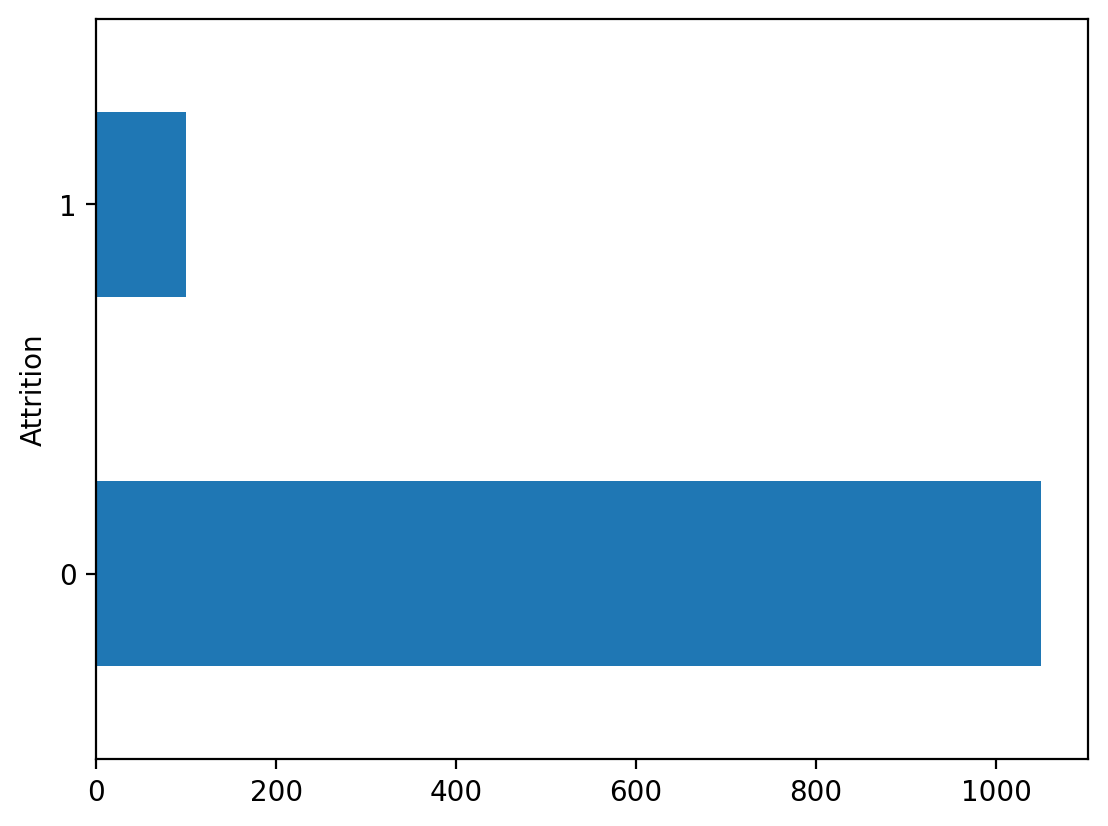

In [19]:
# Target 확인
print(df['Attrition'].value_counts())

# 시각화
df['Attrition'].value_counts().plot(kind='barh')
plt.show()

# 3.데이터 전처리

**1) 가변수화**

In [20]:
# 가변수화
dumm_cols = ['Education', 'Department', 'EducationField', 'Gender', 'JobRole', 'JobSatisfaction',
             'MaritalStatus', 'RelationshipSatisfaction', 'WorkLifeBalance']

df = pd.get_dummies(df, columns=dumm_cols, drop_first=True)

**2) x, y 분리**

In [21]:
# target 확인
target = 'Attrition'

# 데이터 분리
X = df.drop(target, axis=1)
y = df.loc[:, target]

**3) 학습용, 평가용 데이터 분리**

In [22]:
# 모듈 불러오기
from sklearn.model_selection import train_test_split

# 7:3으로 분리
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.3,
                                                    random_state=1)

# 4.모델링

## 4.1.기본 모델링

- 원본 데이터를 사용해 Random Forest 알고리즘으로 모델링한다.

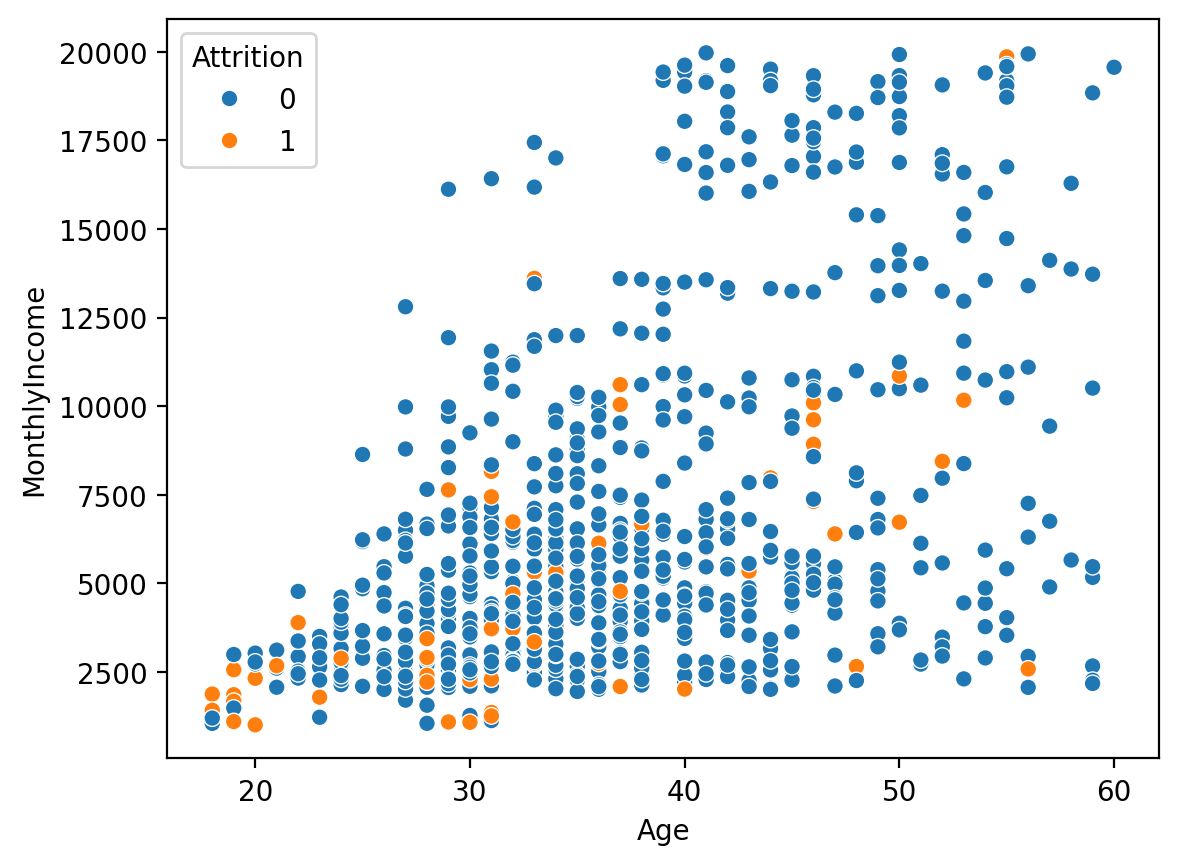

In [23]:
# 학습 데이터 분포 확인
sns.scatterplot(x='Age', y='MonthlyIncome', hue=y_train, data=X_train)
plt.show()

In [24]:
# 불러오기
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *

# 선언하기
model = RandomForestClassifier(max_depth=5, random_state=1)

# 학습하기
model.fit(X_train, y_train)

# 예측하기
y_pred = model.predict(X_test)

# 평가하기
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[317   1]
 [ 26   1]]
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       318
           1       0.50      0.04      0.07        27

    accuracy                           0.92       345
   macro avg       0.71      0.52      0.51       345
weighted avg       0.89      0.92      0.89       345



- Accuracy(정확도)는 높지만 Target 값 1에 대한 Recall(재현율, 민감도)이 매우 낮다.
- 전체 데이터 중에서 Target 값이 1인 데이터가 매우 적기 때문이다.
- 이러한 현상을 **클래스 불균형** 이라고 하는데, 실무에서는 Accuracy가 낮아지더라도 1에 대한 Recall을 높여야 할 경우가 종종 있다.
- 이를 위해 **Under Sampling** 또는 **Over Sampling** 을 사용한다.

## 4.2.Under Sampling

- Under Sampling 후 모델 성능을 확인한다.

**1) Under Sampling**

- RandomUnderSampler를 사용해 Under Sampling 한다.

In [25]:
# imblearn 설치
#!pip install imbalanced-learn

In [26]:
# 불러오기
from imblearn.under_sampling import RandomUnderSampler

# Under Sampling
under_sample = RandomUnderSampler()
u_X_train, u_y_train = under_sample.fit_resample(X_train, y_train)

# 확인
print('전:', np.bincount(y_train))
print('후:', np.bincount(u_y_train))

전: [732  73]
후: [73 73]


**2) 학습 데이터 분포 확인**

- 시각화해서 Resampling 된 학습 데이터 분포 확인

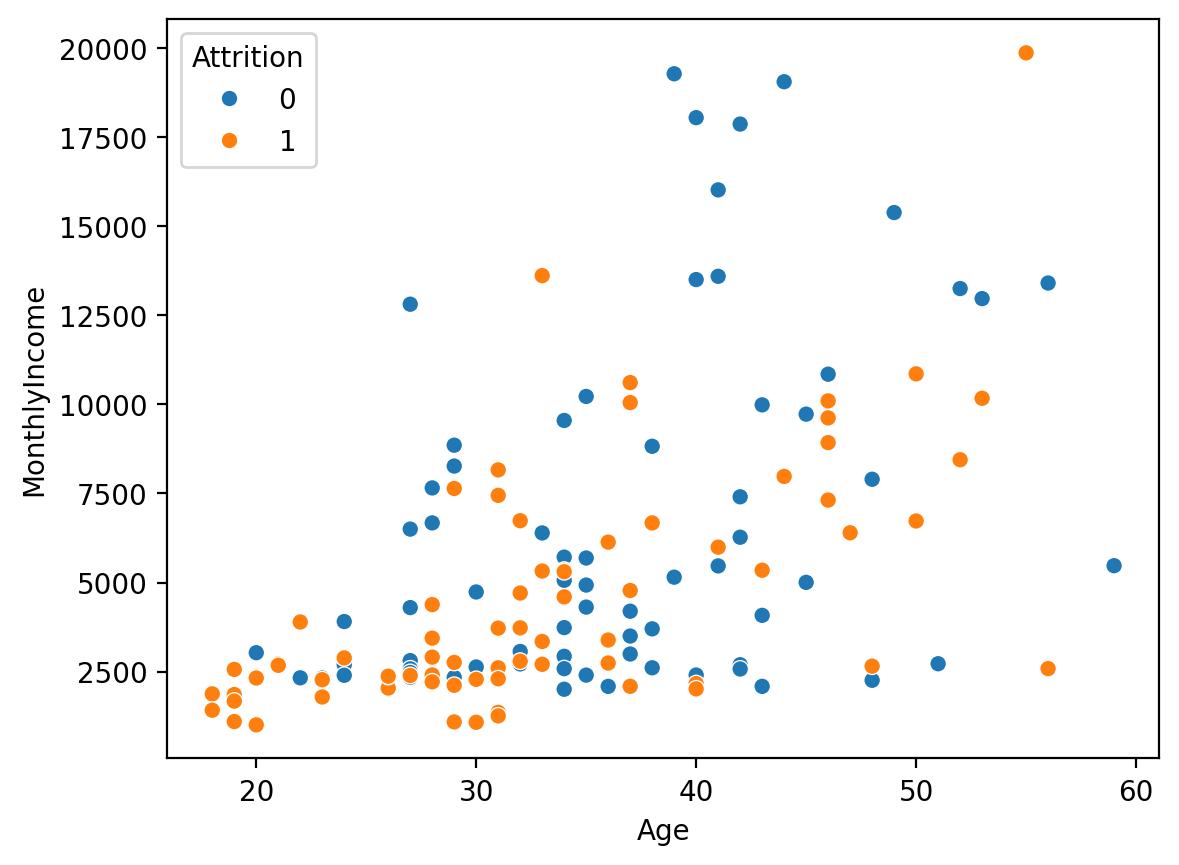

In [27]:
# 학습 데이터 분포 확인
sns.scatterplot(x='Age', y='MonthlyIncome', hue=u_y_train, data=u_X_train)
plt.show()

**3) 모델 성능 확인**

- 다시 모델링해 성능을 확인한다.

In [28]:
# 선언하기
model = RandomForestClassifier(max_depth=5, random_state=1)

# 학습하기
model.fit(u_X_train, u_y_train)

# 예측하기
y_pred = model.predict(X_test)

# 평가하기
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[223  95]
 [ 14  13]]
              precision    recall  f1-score   support

           0       0.94      0.70      0.80       318
           1       0.12      0.48      0.19        27

    accuracy                           0.68       345
   macro avg       0.53      0.59      0.50       345
weighted avg       0.88      0.68      0.76       345



## 4.3.Over Sampling #1

- Over Sampling 후 모델 성능을 확인한다.

**1) Over Sampling**

- RandomOverSampler를 사용해 Over Sampling 한다.

In [29]:
# 불러오기
from imblearn.over_sampling import RandomOverSampler

# Over Sampling
over_sample = RandomOverSampler()
o_X_train, o_y_train = over_sample.fit_resample(X_train, y_train)

# 확인
print('전:', np.bincount(y_train))
print('후:', np.bincount(o_y_train))

전: [732  73]
후: [732 732]


**2) 학습 데이터 분포 확인**

- 시각화해서 Resampling 된 학습 데이터 분포 확인

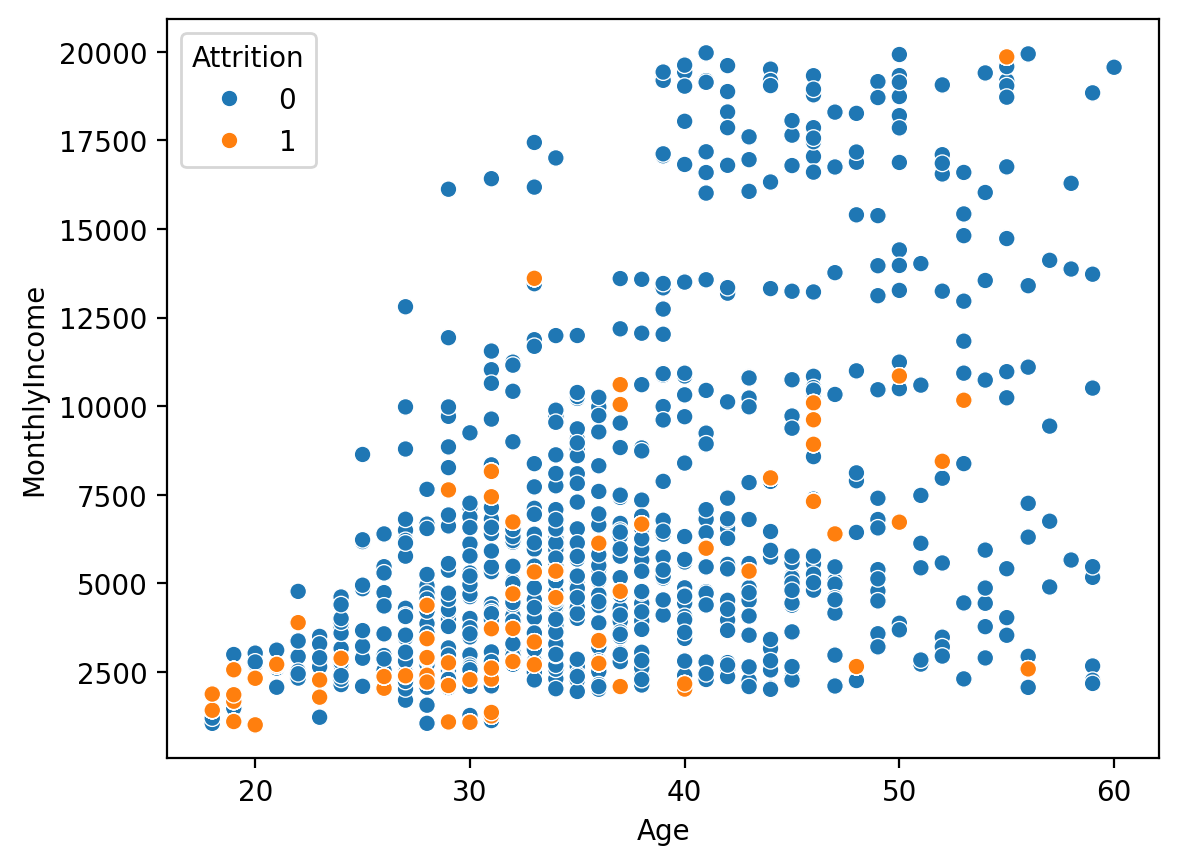

In [30]:
# 학습 데이터 분포 확인
sns.scatterplot(x='Age', y='MonthlyIncome', hue=o_y_train, data=o_X_train)
plt.show()

**3) 모델 성능 확인**

- 다시 모델링해 성능을 확인한다.

In [31]:
# 선언하기
model = RandomForestClassifier(max_depth=5, random_state=1)

# 학습하기
model.fit(o_X_train, o_y_train)

# 예측하기
y_pred = model.predict(X_test)

# 평가하기
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[286  32]
 [ 16  11]]
              precision    recall  f1-score   support

           0       0.95      0.90      0.92       318
           1       0.26      0.41      0.31        27

    accuracy                           0.86       345
   macro avg       0.60      0.65      0.62       345
weighted avg       0.89      0.86      0.87       345



## 4.4.Over Sampling #2

- Over Sampling 후 모델 성능을 확인한다.

**1) Over Sampling**

- SMOTE를 사용해 Over Sampling 한다.
- SMOTE(Synthetic Minority Over-sampling Technique)
- SMOTE는 소수 클래스 샘플을 단순 복제하는 것이 아니라, 기존 샘플을 기반으로 새로운 샘플을 합성하여 생성하는 기법이다.

In [32]:
# 불러오기
from imblearn.over_sampling import SMOTE

# Over Sampling
smote = SMOTE()
s_X_train, s_y_train = smote.fit_resample(X_train, y_train)

# 확인
print('전:', np.bincount(y_train))
print('후:', np.bincount(s_y_train))

전: [732  73]
후: [732 732]


**2) 학습 데이터 분포 확인**

- 시각화해서 Resampling 된 학습 데이터 분포 확인

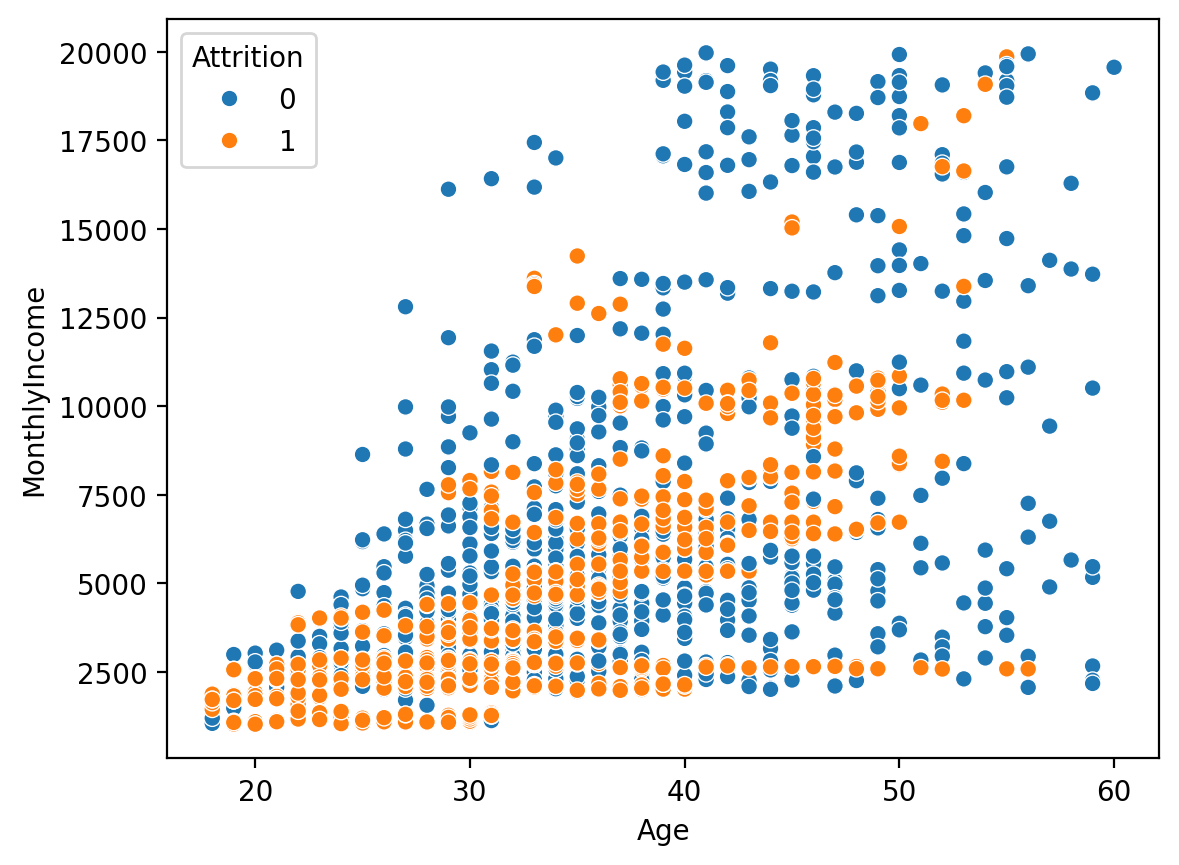

In [33]:
# 학습 데이터 분포 확인
sns.scatterplot(x='Age', y='MonthlyIncome', hue=s_y_train, data=s_X_train)
plt.show()

**3) 모델 성능 확인**

- 다시 모델링해 성능을 확인한다.

In [34]:
# 선언하기
model = RandomForestClassifier(max_depth=5, random_state=1)

# 학습하기
model.fit(s_X_train, s_y_train)

# 예측하기
y_pred = model.predict(X_test)

# 평가하기
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[303  15]
 [ 16  11]]
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       318
           1       0.42      0.41      0.42        27

    accuracy                           0.91       345
   macro avg       0.69      0.68      0.68       345
weighted avg       0.91      0.91      0.91       345



## 4.5.Class Weight

- class_weight 하이퍼파라미터를 설정해 모델링한 후 성능을 확인한다.
- sklearn에서 제공하는 알고리즘 대부분 class_weight라는 하이퍼파라미터 제공

In [35]:
# 선언하기
model = RandomForestClassifier(max_depth=5, random_state=1, class_weight='balanced')

# 학습하기
model.fit(X_train, y_train)

# 예측하기
y_pred = model.predict(X_test)

# 평가하기
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[302  16]
 [ 17  10]]
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       318
           1       0.38      0.37      0.38        27

    accuracy                           0.90       345
   macro avg       0.67      0.66      0.66       345
weighted avg       0.90      0.90      0.90       345

